<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/21_custom_model_residual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 21 — Custom Model: ResidualBlock & ResidualRegressor

## What This Notebook Covers
When `Sequential` is not enough, subclass `tf.keras.Model` to build
architectures with:
- Multiple inputs or outputs
- Skip connections (residual learning)
- Branching paths
- Shared layers
- Dynamic computation graphs

**Models built (following Géron Chapter 12):**
- `ResidualBlock` — custom layer with skip connection
- `ResidualRegressor` — stacks ResidualBlocks for regression
- `WideAndDeepModel` — two separate paths merged at output
- `MultiOutputModel` — shared trunk with two separate heads

**Key patterns learned:**
- Subclassing `tf.keras.Model` vs `tf.keras.layers.Layer`
- Defining sub-layers in `__init__`, wiring them in `call()`
- Multiple inputs and outputs in `call()`
- Training with multiple losses

**Both TensorFlow and PyTorch shown.**

**Dataset:** California Housing (regression) + Fashion-MNIST (classification)


In [1]:
import tensorflow as tf
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

tf.random.set_seed(42)
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('TensorFlow:', tf.__version__)
print('PyTorch   :', torch.__version__)
print('Device    :', device)

TensorFlow: 2.20.0
PyTorch   : 2.10.0+cu128
Device    : cuda


## 1. Load Data


In [2]:
# California Housing — regression
housing = fetch_california_housing()
X_reg, y_reg = housing.data.astype(np.float32), housing.target.astype(np.float32)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
X_reg_train, X_reg_valid, y_reg_train, y_reg_valid = train_test_split(
    X_reg_train, y_reg_train, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_reg_train = scaler.fit_transform(X_reg_train).astype(np.float32)
X_reg_valid = scaler.transform(X_reg_valid).astype(np.float32)
X_reg_test  = scaler.transform(X_reg_test).astype(np.float32)
print(f'Regression — Train: {X_reg_train.shape}')

# Fashion-MNIST — classification
(X_cls_full, y_cls_full), (X_cls_test, y_cls_test) = tf.keras.datasets.fashion_mnist.load_data()
X_cls_full  = X_cls_full.astype('float32') / 255.0
X_cls_test  = X_cls_test.astype('float32')  / 255.0
X_cls_train = X_cls_full[5000:].reshape(-1, 784)
X_cls_valid = X_cls_full[:5000].reshape(-1, 784)
X_cls_test  = X_cls_test.reshape(-1, 784)
y_cls_train = y_cls_full[5000:]
y_cls_valid = y_cls_full[:5000]
print(f'Classification — Train: {X_cls_train.shape}')

# PyTorch Fashion-MNIST
transform = transforms.Compose([
    transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))
])
train_full_pt = datasets.FashionMNIST('./data', train=True,  download=True, transform=transform)
test_set_pt   = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
train_pt, valid_pt = torch.utils.data.random_split(
    train_full_pt, [55000, 5000], generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_pt, batch_size=64, shuffle=True,  pin_memory=True)
valid_loader = DataLoader(valid_pt, batch_size=64, shuffle=False, pin_memory=True)

Regression — Train: (13209, 8)
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Classification — Train: (55000, 784)


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.2MB/s]


---
## Part A — TensorFlow / Keras

## 2. ResidualBlock — Custom Layer with Skip Connection

A ResidualBlock contains two Dense layers and adds the block input
to the block output. The model only needs to learn the **residual** —
how much to change the input — rather than a full transformation.

This is a `Layer` (not a `Model`) because it is a component used inside
larger models, not a standalone trainable unit.


In [3]:
class ResidualBlock(tf.keras.layers.Layer):
    """
    Residual block: output = ReLU( Dense(Dense(x)) + skip(x) )

    The skip connection adds the block input to the output so
    the model only needs to learn the residual (delta) from
    the identity mapping.

    If n_layers Dense layers are applied and the dimension does not
    change, the skip is the raw input. If it changes, a projection
    Dense maps the skip to match the output dimension.

    Key insight: gradients flow directly through the skip connection,
    preventing vanishing gradients in deep networks.
    """
    def __init__(self, n_layers, n_units, **kwargs):
        super().__init__(**kwargs)
        self.n_layers = n_layers
        self.n_units  = n_units

        # Main path: n_layers Dense layers
        self.hidden_layers = [
            tf.keras.layers.Dense(
                n_units,
                activation='relu',
                kernel_initializer='he_normal'
            )
            for _ in range(n_layers)
        ]
        self.bn_layers = [
            tf.keras.layers.BatchNormalization()
            for _ in range(n_layers)
        ]
        # Projection for skip connection (used if input dim != n_units)
        self.skip_projection = tf.keras.layers.Dense(n_units)

    def call(self, inputs, training=None):
        Z = inputs
        # Pass through the main path
        for dense, bn in zip(self.hidden_layers, self.bn_layers):
            Z = dense(Z)
            Z = bn(Z, training=training)

        # Skip connection: project if input dim != output dim
        skip = (self.skip_projection(inputs)
                if inputs.shape[-1] != self.n_units
                else inputs)

        # Add skip to main path, then apply non-linearity
        return tf.keras.activations.relu(Z + skip)

    def get_config(self):
        config = super().get_config()
        config.update({'n_layers': self.n_layers, 'n_units': self.n_units})
        return config


# Verify
block    = ResidualBlock(n_layers=2, n_units=64)
test_in  = tf.random.normal([4, 128])   # 128 -> 64, projection needed
test_out = block(test_in)
print(f'ResidualBlock (128->64) output shape: {test_out.shape}  (expect (4, 64))')

block2   = ResidualBlock(n_layers=2, n_units=128)
test_out2 = block2(test_in)
print(f'ResidualBlock (128->128) output shape: {test_out2.shape}  (expect (4, 128))')

ResidualBlock (128->64) output shape: (4, 64)  (expect (4, 64))
ResidualBlock (128->128) output shape: (4, 128)  (expect (4, 128))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'residual_block_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


## 3. ResidualRegressor — Subclassing tf.keras.Model

Subclassing `tf.keras.Model` gives full control over the forward pass.
Define sub-layers in `__init__`, wire them in `call()`.

Use `Model` (not `Layer`) when the object is a complete trainable unit
that you call `compile()`, `fit()`, `evaluate()`, `predict()` on.


In [4]:
class ResidualRegressor(tf.keras.Model):
    """
    Regression model built from stacked ResidualBlocks.

    Architecture:
      Input -> Dense (embedding) -> N x ResidualBlock -> Dense (output)

    The embedding layer projects the raw input into n_units dimensions
    so that all ResidualBlocks can operate at the same dimension
    (no projection needed inside the blocks).
    """
    def __init__(self, n_blocks=4, n_units=64,
                 n_layers_per_block=2, **kwargs):
        super().__init__(**kwargs)
        self.n_blocks           = n_blocks
        self.n_units            = n_units
        self.n_layers_per_block = n_layers_per_block

        # Project raw input to n_units dimensions
        self.embedding = tf.keras.layers.Dense(
            n_units, activation='relu', kernel_initializer='he_normal'
        )
        # Stack of residual blocks
        self.res_blocks = [
            ResidualBlock(
                n_layers=n_layers_per_block,
                n_units=n_units,
                name=f'res_block_{i}'
            )
            for i in range(n_blocks)
        ]
        # Single scalar output for regression
        self.output_layer = tf.keras.layers.Dense(1)

    def call(self, inputs, training=None):
        x = self.embedding(inputs)
        for block in self.res_blocks:
            x = block(x, training=training)
        return self.output_layer(x)

    def get_config(self):
        config = super().get_config()
        config.update({
            'n_blocks':            self.n_blocks,
            'n_units':             self.n_units,
            'n_layers_per_block':  self.n_layers_per_block
        })
        return config


# Build and inspect
residual_regressor = ResidualRegressor(n_blocks=4, n_units=64, n_layers_per_block=2)
_ = residual_regressor(tf.zeros([1, X_reg_train.shape[1]]))  # build
residual_regressor.summary()
print(f'\nTotal parameters: {residual_regressor.count_params():,}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_block_0', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_block_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_block_2', however the layer does not 

Model: "residual_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (1, 64)                │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_0 (ResidualBlock)     │ ?                      │         8,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_1 (ResidualBlock)     │ ?                      │         8,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_2 (ResidualBlock)     │ ?                      │         8,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_3 (ResidualBlock)     │ ?                      │         8,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (1, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,969 (140.50 KB)

 Trainable params: 34,945 (136.50 KB)

 Non-trainable params: 1,024 (4.00 KB)


Total parameters: 35,969


## 4. A/B Test: Standard MLP vs ResidualRegressor


Standard Deep MLP (8 layers)        -> test MAE: 0.4911
ResidualRegressor (4 blocks)        -> test MAE: 0.5755


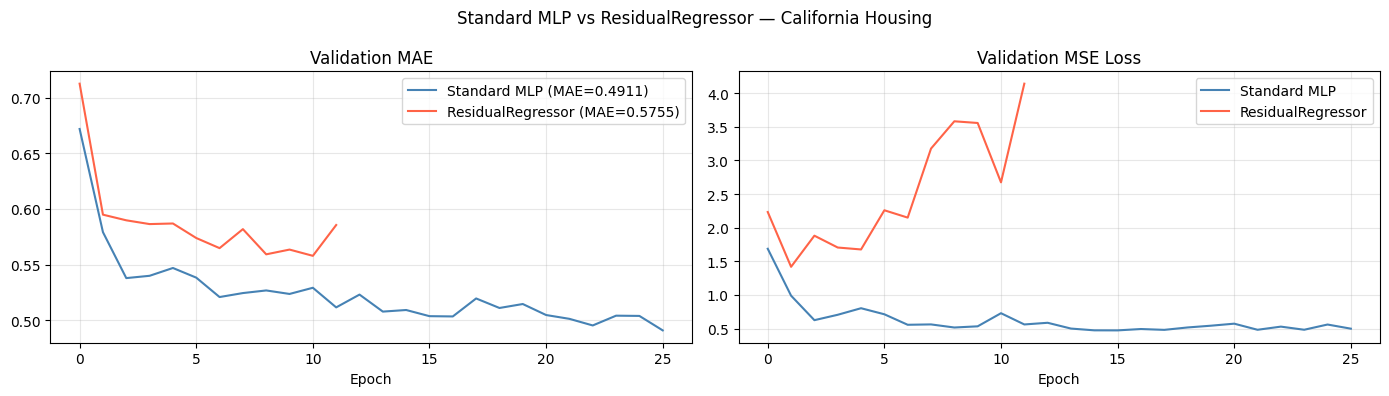

In [5]:
def make_standard_mlp(n_units=64, n_layers=8):
    """Deep MLP with same total parameters as ResidualRegressor but no skip."""
    layers = [tf.keras.layers.Input(shape=(X_reg_train.shape[1],))]
    x = tf.keras.layers.Dense(
        n_units, activation='relu', kernel_initializer='he_normal'
    )(layers[0])
    for _ in range(n_layers - 1):
        x = tf.keras.layers.Dense(
            n_units, activation='relu', kernel_initializer='he_normal'
        )(x)
        x = tf.keras.layers.BatchNormalization()(x)
    output = tf.keras.layers.Dense(1)(x)
    return tf.keras.Model(inputs=layers[0], outputs=output)


def train_regressor(model, label, epochs=50):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='mse',
        metrics=['mae']
    )
    h = model.fit(
        X_reg_train, y_reg_train,
        validation_data=(X_reg_valid, y_reg_valid),
        epochs=epochs, batch_size=64,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            patience=10, restore_best_weights=True)],
        verbose=0
    )
    test_loss, test_mae = model.evaluate(X_reg_test, y_reg_test, verbose=0)
    print(f'{label:35s} -> test MAE: {test_mae:.4f}')
    return h, test_mae


tf.random.set_seed(42)
std_mlp = make_standard_mlp(n_units=64, n_layers=8)
h_mlp, mae_mlp = train_regressor(std_mlp, 'Standard Deep MLP (8 layers)')

tf.random.set_seed(42)
res_reg = ResidualRegressor(n_blocks=4, n_units=64, n_layers_per_block=2)
h_res, mae_res = train_regressor(res_reg, 'ResidualRegressor (4 blocks)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(h_mlp.history['val_mae'], color='steelblue',
             label=f'Standard MLP (MAE={mae_mlp:.4f})')
axes[0].plot(h_res.history['val_mae'], color='tomato',
             label=f'ResidualRegressor (MAE={mae_res:.4f})')
axes[0].set_title('Validation MAE')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(h_mlp.history['val_loss'], color='steelblue', label='Standard MLP')
axes[1].plot(h_res.history['val_loss'], color='tomato',    label='ResidualRegressor')
axes[1].set_title('Validation MSE Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Standard MLP vs ResidualRegressor — California Housing', fontsize=12)
plt.tight_layout()
plt.show()

## 5. WideAndDeepModel — Two Input Paths

The Wide & Deep architecture (Cheng et al. 2016, Google Play) routes
some features through a deep path and others through a wide (direct) path,
then concatenates both at the output.

This is impossible with Sequential — it requires the Functional API
or Model subclassing.


In [6]:
class WideAndDeepModel(tf.keras.Model):
    """
    Wide & Deep architecture with two input paths.

    - Deep path: all features -> several Dense layers -> output
    - Wide path: subset of features -> directly to output (skip deep)
    - Final: concatenate deep and wide, then predict

    The wide path memorizes specific feature combinations.
    The deep path generalizes via learned representations.

    Usage:
        model = WideAndDeepModel(n_hidden=[64, 64])
        # wide_input: subset of features (e.g. first 5)
        # deep_input: all features
        output = model([wide_input, deep_input])
    """
    def __init__(self, n_hidden=(64, 64), activation='relu', **kwargs):
        super().__init__(**kwargs)
        self.hidden = [
            tf.keras.layers.Dense(units, activation=activation,
                                   kernel_initializer='he_normal')
            for units in n_hidden
        ]
        self.bn_layers = [
            tf.keras.layers.BatchNormalization()
            for _ in n_hidden
        ]
        self.output_layer = tf.keras.layers.Dense(1)

    def call(self, inputs, training=None):
        # Unpack the two inputs
        wide_input, deep_input = inputs

        # Deep path
        deep = deep_input
        for dense, bn in zip(self.hidden, self.bn_layers):
            deep = dense(deep)
            deep = bn(deep, training=training)

        # Concatenate wide and deep
        concat = tf.concat([wide_input, deep], axis=1)

        # Final prediction
        return self.output_layer(concat)


# Prepare two-input data
# Wide: first 5 features (geography/demographics)
# Deep: all 8 features
N_WIDE = 5

X_train_wide  = X_reg_train[:, :N_WIDE]
X_valid_wide  = X_reg_valid[:, :N_WIDE]
X_test_wide   = X_reg_test[:,  :N_WIDE]

tf.random.set_seed(42)
wide_deep_model = WideAndDeepModel(n_hidden=(64, 64))
wide_deep_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse', metrics=['mae']
)

# Pass a LIST of two inputs to fit
h_wd = wide_deep_model.fit(
    [X_train_wide, X_reg_train], y_reg_train,
    validation_data=([X_valid_wide, X_reg_valid], y_reg_valid),
    epochs=30, batch_size=64,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        patience=8, restore_best_weights=True)],
    verbose=0
)
_, wd_mae = wide_deep_model.evaluate(
    [X_test_wide, X_reg_test], y_reg_test, verbose=0
)
print(f'Wide & Deep test MAE: {wd_mae:.4f}')
print(f'Standard MLP test MAE: {mae_mlp:.4f}')
print(f'ResidualRegressor MAE: {mae_res:.4f}')

Wide & Deep test MAE: 0.5449
Standard MLP test MAE: 0.4911
ResidualRegressor MAE: 0.5755


## 6. MultiOutputModel — Shared Trunk, Two Heads

Fashion-MNIST has 10 clothing classes. We build a model that predicts:
1. The exact class (10-way softmax)
2. Whether it is footwear or not (binary sigmoid)

Both heads share the same feature extractor (trunk).
This is multi-task learning — sharing representations improves both tasks.


Multi-output model test results:
  loss: 0.3555
  compile_metrics: 0.3520
  class_out_loss: 0.0061
  footwear_out_loss: 0.8734


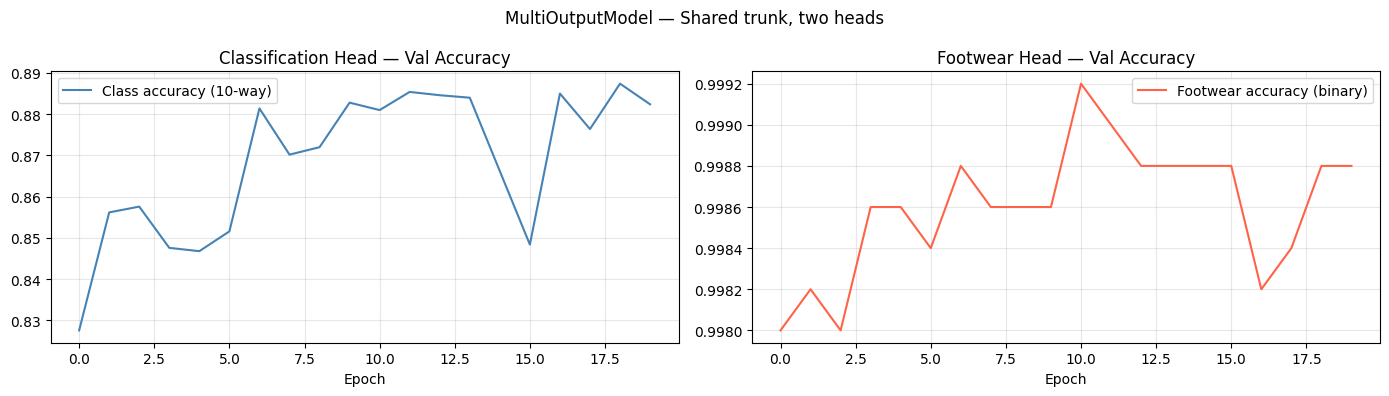

In [9]:
CLASS_NAMES = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']
FOOTWEAR_IDX = [5, 7, 9]  # Sandal, Sneaker, Ankle boot

y_footwear_train = np.isin(y_cls_train, FOOTWEAR_IDX).astype(np.float32)
y_footwear_valid = np.isin(y_cls_valid, FOOTWEAR_IDX).astype(np.float32)
y_footwear_test  = np.isin(y_cls_test,  FOOTWEAR_IDX).astype(np.float32)


class MultiOutputModel(tf.keras.Model):
    """
    Shared trunk with two separate output heads:
    1. class_output  : 10-way softmax for clothing category
    2. footwear_output: binary sigmoid for is_footwear

    Shared trunk: forces both tasks to use the same features.
    This is regularizing — both tasks constrain the learned representation.

    Training: pass a dict of targets {'class_out': y_class, 'footwear': y_fw}
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Shared trunk
        self.dense1     = tf.keras.layers.Dense(256, activation='relu',
                                                 kernel_initializer='he_normal')
        self.bn1        = tf.keras.layers.BatchNormalization()
        self.drop1      = tf.keras.layers.Dropout(0.3)
        self.dense2     = tf.keras.layers.Dense(128, activation='relu',
                                                 kernel_initializer='he_normal')
        self.bn2        = tf.keras.layers.BatchNormalization()
        self.drop2      = tf.keras.layers.Dropout(0.3)

        # Task-specific heads
        self.class_head    = tf.keras.layers.Dense(10, activation='softmax',
                                                    name='class_out')
        self.footwear_head = tf.keras.layers.Dense(1,  activation='sigmoid',
                                                    name='footwear_out')
        # Explicitly define output names for Keras to recognize them
        self.output_names = ['class_out', 'footwear_out']

    def call(self, inputs, training=None):
        # Shared trunk
        x = self.dense1(inputs)
        x = self.bn1(x, training=training)
        x = self.drop1(x, training=training)
        x = self.dense2(x)
        x = self.bn2(x, training=training)
        x = self.drop2(x, training=training)

        # Two separate heads from the same trunk
        class_pred    = self.class_head(x)
        footwear_pred = self.footwear_head(x)

        return class_pred, footwear_pred


tf.random.set_seed(42)
multi_model = MultiOutputModel()
# Explicitly build the model to ensure output names are registered
_ = multi_model(tf.zeros((1, X_cls_train.shape[1])))
multi_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    # Dict mapping output name to loss
    loss={
        'class_out':    'sparse_categorical_crossentropy',
        'footwear_out': 'binary_crossentropy'
    },
    # Weight the losses (classification is more important)
    loss_weights={'class_out': 1.0, 'footwear_out': 0.5},
    metrics={
        'class_out':    'accuracy',
        'footwear_out': 'accuracy'
    }
)

h_multi = multi_model.fit(
    X_cls_train,
    # Dict of targets matching output names
    {'class_out': y_cls_train, 'footwear_out': y_footwear_train},
    validation_data=(
        X_cls_valid,
        {'class_out': y_cls_valid, 'footwear_out': y_footwear_valid}
    ),
    epochs=20, batch_size=64,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        patience=5, restore_best_weights=True)],
    verbose=0
)

results = multi_model.evaluate(
    X_cls_test,
    {'class_out': y_cls_test, 'footwear_out': y_footwear_test},
    verbose=0
)
print('Multi-output model test results:')
for name, val in zip(multi_model.metrics_names, results):
    print(f'  {name}: {val:.4f}')

# Plot both task learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(h_multi.history['val_class_out_accuracy'],
             color='steelblue', label='Class accuracy (10-way)')
axes[0].set_title('Classification Head — Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(h_multi.history['val_footwear_out_accuracy'],
             color='tomato', label='Footwear accuracy (binary)')
axes[1].set_title('Footwear Head — Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('MultiOutputModel — Shared trunk, two heads', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Save and Reload Custom Model


In [10]:
res_reg.save('/tmp/residual_regressor.keras')
print('ResidualRegressor saved.')

loaded = tf.keras.models.load_model(
    '/tmp/residual_regressor.keras',
    custom_objects={'ResidualRegressor': ResidualRegressor,
                    'ResidualBlock':     ResidualBlock}
)
print('Loaded successfully.')

orig_pred   = res_reg.predict(X_reg_test[:10], verbose=0)
loaded_pred = loaded.predict(X_reg_test[:10], verbose=0)
print(f'Max diff: {np.abs(orig_pred - loaded_pred).max():.2e}  (expect ~0)')

ResidualRegressor saved.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_block_0', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_block_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_block_2', however the layer does not 

Loaded successfully.
Max diff: 0.00e+00  (expect ~0)


---
## Part B — PyTorch Custom Models

## 8. ResidualBlock and ResidualClassifier in PyTorch


Training Standard MLP...
[Standard MLP] Epoch  5 | val=0.8756
[Standard MLP] Epoch 10 | val=0.8894
[Standard MLP] Epoch 15 | val=0.8970
[Standard MLP] Epoch 20 | val=0.8954
[Standard MLP] Best val acc: 0.8978

Training ResidualClassifier...
[ResidualClassifier] Epoch  5 | val=0.8764
[ResidualClassifier] Epoch 10 | val=0.8864
[ResidualClassifier] Epoch 15 | val=0.8976
[ResidualClassifier] Epoch 20 | val=0.9000
[ResidualClassifier] Best val acc: 0.9000



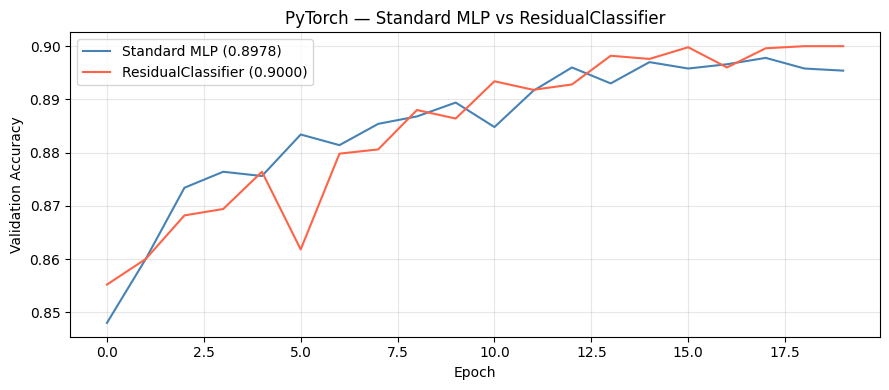

In [11]:
class ResidualBlockPT(nn.Module):
    """
    PyTorch residual block.
    In PyTorch, shapes must be specified explicitly (no lazy build).
    """
    def __init__(self, in_features, n_units, n_layers=2):
        super().__init__()
        layers = []
        dim = in_features
        for _ in range(n_layers):
            layers += [
                nn.Linear(dim, n_units),
                nn.BatchNorm1d(n_units),
                nn.ReLU()
            ]
            dim = n_units
        self.main_path = nn.Sequential(*layers)

        # Project skip if dimensions differ
        self.skip = (
            nn.Linear(in_features, n_units)
            if in_features != n_units else nn.Identity()
        )

    def forward(self, x):
        return torch.relu(self.main_path(x) + self.skip(x))


class ResidualClassifierPT(nn.Module):
    """
    Fashion-MNIST classifier using stacked ResidualBlocks.
    """
    def __init__(self, n_blocks=4, n_units=128, n_classes=10):
        super().__init__()
        self.flatten   = nn.Flatten()
        self.embedding = nn.Sequential(
            nn.Linear(784, n_units), nn.ReLU()
        )
        # All blocks at same dimension — no projection after first
        self.blocks = nn.ModuleList([
            ResidualBlockPT(n_units, n_units, n_layers=2)
            for _ in range(n_blocks)
        ])
        self.classifier = nn.Linear(n_units, n_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.embedding(x)
        for block in self.blocks:
            x = block(x)
        return self.classifier(x)


# Baseline: standard deep MLP
class StandardMLPPT(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, n_classes)
        )
    def forward(self, x): return self.net(x)


def train_pt(model_factory, label, epochs=20):
    torch.manual_seed(42)
    model     = model_factory().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    best_acc  = 0.0
    hist      = []

    for epoch in range(epochs):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(model(X_b), y_b).backward()
            optimizer.step()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for X_b, y_b in valid_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                correct += (model(X_b).argmax(1) == y_b).sum().item()
                total   += y_b.size(0)
        val_acc  = correct / total
        best_acc = max(best_acc, val_acc)
        hist.append(val_acc)
        scheduler.step()

        if (epoch + 1) % 5 == 0:
            print(f'[{label}] Epoch {epoch+1:2d} | val={val_acc:.4f}')

    print(f'[{label}] Best val acc: {best_acc:.4f}\n')
    return hist, best_acc


print('Training Standard MLP...')
hist_std, acc_std = train_pt(StandardMLPPT, 'Standard MLP', epochs=20)

print('Training ResidualClassifier...')
hist_res, acc_res = train_pt(
    lambda: ResidualClassifierPT(n_blocks=4, n_units=128),
    'ResidualClassifier', epochs=20
)

plt.figure(figsize=(9, 4))
plt.plot(hist_std, color='steelblue', label=f'Standard MLP ({acc_std:.4f})')
plt.plot(hist_res, color='tomato',    label=f'ResidualClassifier ({acc_res:.4f})')
plt.title('PyTorch — Standard MLP vs ResidualClassifier')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

### Layer vs Model Subclassing

| | `tf.keras.layers.Layer` | `tf.keras.Model` |
|---|---|---|
| Use when | Building a block/component | Building a complete trainable unit |
| Can call `fit()`? | No | Yes |
| Has `compile()`? | No | Yes |
| Has `summary()`? | No | Yes |
| Has `save()`? | Partial | Full |
| Example | `ResidualBlock` | `ResidualRegressor` |

### Patterns Demonstrated

| Pattern | Example | Key technique |
|---|---|---|
| Skip connection | `ResidualBlock` | `output = activation(F(x) + skip(x))` |
| Stacked blocks | `ResidualRegressor` | `ModuleList` / Python list of layers |
| Multiple inputs | `WideAndDeepModel` | `inputs = [wide, deep]` in `call()` |
| Multiple outputs | `MultiOutputModel` | Return tuple `(out1, out2)` from `call()` |
| Multiple losses | `MultiOutputModel` | `loss={'name1': ..., 'name2': ...}` |

### Why Skip Connections Work
```
Standard layer: output = F(x)
Residual layer: output = F(x) + x

Gradient to x:
  d(output)/dx = dF/dx + 1   <- the +1 prevents vanishing gradients

Even if dF/dx -> 0 (vanishing), the gradient is still 1.
Early layers always receive at least gradient = 1.
```

**Next: Notebook 22** — Custom Optimizer (MyMomentumOptimizer)
